Running AlievPanfilov on [3, 3] Grid: 100%|██████████| 10/10 [00:00<00:00, 48.73it/s]


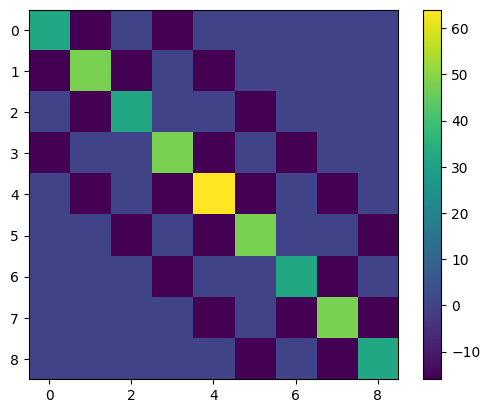

In [1]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 3
tissue = fw.CardiacTissueGrid([n, n], dr=0.25)
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.3).astype(tissue.mesh.dtype)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=n//2 - 3, x_max=n//2 + 3,
                                           y_min=n//2 - 3, y_max=n//2 + 3))

diffusion_model = fw.GridModel()
diffusion_model.stencil = fw.IsotropicStencil()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 0.1
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model

# run the model:
simulation.run()

K, M = simulation.diffusion_model.weights

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
plt.figure()
plt.imshow(K.toarray())
plt.colorbar()
plt.show()


In [6]:
np.roll(np.arange(3), -1), np.roll(np.arange(3), 2)

(array([1, 2, 0]), array([1, 2, 0]))